[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/


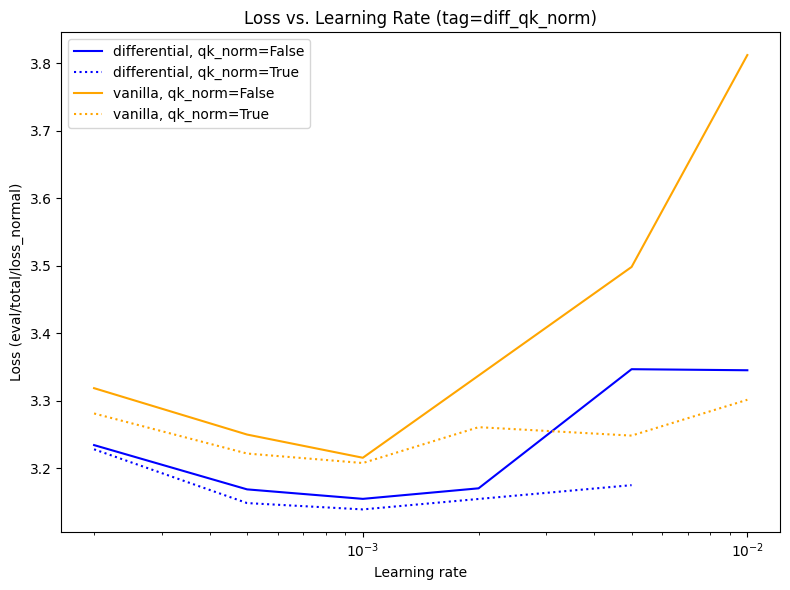

In [3]:
import neptune
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Neptune (make sure your API token and project are set, e.g. via environment variables)
# e.g. NEPTUNE_API_TOKEN and NEPTUNE_PROJECT
y_axis = "eval/total_loss/normal"
run_table = neptune.init_project(project="pmtest/llm-random").fetch_runs_table(
    tag=["diff_qk_norm"],
    columns=[
        "sys/id",
        "args/attention_mode",
        "args/use_qk_norm",
        "args/learning_rate",
        "eval/total_loss/normal",
    ],
)
plot_df = run_table.to_pandas()
plot_df = plot_df.sort_values(by=["args/attention_mode", "args/use_qk_norm", "args/learning_rate"])
plot_df.dropna(inplace=True)
# plot_df = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(8, 6))
for att_mode, subdf in plot_df.groupby("args/attention_mode"):
    color = "blue" if att_mode == "differential" else "orange"
    for qk_norm, qdf in subdf.groupby("args/use_qk_norm"):
        linestyle = ":" if qk_norm else "-"
        plt.plot(
            qdf["args/learning_rate"].to_numpy(),
            qdf[y_axis].to_numpy(),
            linestyle=linestyle,
            color=color,
            label=f"{att_mode}, qk_norm={qk_norm}",
        )

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss (eval/total/loss_normal)")
plt.title("Loss vs. Learning Rate (tag=diff_qk_norm)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
plot_df

,sys/creation_time,sys/id,args/attention_mode,args/learning_rate,args/use_qk_norm,eval/total_loss/normal
10,2025-11-10 19:57:21.335,LLMRANDOM-40176,differential,0.0002,False,3.234375
9,2025-11-10 19:58:17.268,LLMRANDOM-40177,differential,0.0005,False,3.168750
7,2025-11-10 20:27:40.001,LLMRANDOM-40179,differential,0.0010,False,3.154688
6,2025-11-10 22:05:19.120,LLMRANDOM-40181,differential,0.0020,False,3.170313
4,2025-11-10 22:17:05.311,LLMRANDOM-40183,differential,0.0050,False,3.346875
3,2025-11-10 22:36:20.250,LLMRANDOM-40185,differential,0.0100,False,3.345312
12,2025-11-10 19:54:23.095,LLMRANDOM-40174,differential,0.0002,True,3.228125
11,2025-11-10 19:57:21.327,LLMRANDOM-40175,differential,0.0005,True,3.148438
8,2025-11-10 20:26:08.521,LLMRANDOM-40178,differential,0.0010,True,3.139063
1,2025-11-11 10:07:47.571,LLMRANDOM-40193,differential,0.0020,True,NaN
